# 2026 Block Manufacturing Production Analysis

## Project Overview

This project analyzes daily production records from January to July 2026 for a block manufacturing production dataset.

The analysis uses Python and Pandas to explore production trends, product contribution, production-day patterns, zero-production periods, and average production per production day.

The dataset has been prepared as a portfolio-safe dataset, with company names, customer information, and other identifying credentials excluded.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "/kaggle/input/datasets/abdulnazercp/2026-block-manufacturing-production-analysis/2026_Block_Manufacturing_Production_Analysis_Kaggle.csv"
)

df.head()

,Date,Month,Day,"CHB 4""","CHB 6""","CHB 8""","HORDI 8""","INS 8""","HORDI 10""",CHB30,...,Remarks,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21
0,"=DATE(2026,1,C2)","=TEXT(A2,""mmm"")",1,16060.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Total Production,=SUM(L2:L213),NaN,Month,Total Production,NaN,NaN
1,"=DATE(2026,1,C3)","=TEXT(A3,""mmm"")",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Friday,NaN,NaN,Production Days,"=COUNTIF(L2:L213,"">0"")",NaN,January,"=SUMIF($B$2:$B$213,LEFT(S3,3),$L$2:$L$213)",NaN,NaN
2,"=DATE(2026,1,C4)","=TEXT(A4,""mmm"")",3,NaN,4240.0,8160.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Zero-Production Days,41,NaN,February,"=SUMIF($B$2:$B$213,LEFT(S4,3),$L$2:$L$213)",NaN,NaN
3,"=DATE(2026,1,C5)","=TEXT(A5,""mmm"")",4,NaN,8800.0,3852.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,Average Production / Production Day,=Q2/Q3,NaN,March,"=SUMIF($B$2:$B$213,LEFT(S5,3),$L$2:$L$213)",NaN,NaN
4,"=DATE(2026,1,C6)","=TEXT(A6,""mmm"")",5,NaN,5120.0,8160.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,April,"=SUMIF($B$2:$B$213,LEFT(S6,3),$L$2:$L$213)",NaN,NaN


In [3]:
# Check the original dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         212 non-null    object 
 1   Month        212 non-null    object 
 2   Day          212 non-null    int64  
 3   CHB 4"       17 non-null     float64
 4   CHB 6"       94 non-null     float64
 5   CHB 8"       138 non-null    float64
 6   HORDI 8"     1 non-null      float64
 7   INS 8"       6 non-null      float64
 8   HORDI 10"    0 non-null      float64
 9   CHB30        0 non-null      float64
 10  INS 30 CM    0 non-null      float64
 11  Total        212 non-null    object 
 12  Remarks      42 non-null     object 
 13  Unnamed: 13  0 non-null      float64
 14  Unnamed: 14  0 non-null      float64
 15  Unnamed: 15  4 non-null      object 
 16  Unnamed: 16  4 non-null      object 
 17  Unnamed: 17  0 non-null      float64
 18  Unnamed: 18  58 non-null     object 
 19  Unnamed:

In [4]:
# Clean and transform the production data
# Keep only the 13 meaningful columns
df = df.iloc[:, :13]

# Extract month number from the original Excel DATE formula
month_numbers = (
    df["Date"]
    .astype(str)
    .str.extract(r"DATE\(2026,(\d+),")[0]
    .astype(int)
)

# Create a proper Date column
df["Date"] = pd.to_datetime({
    "year": 2026,
    "month": month_numbers,
    "day": df["Day"]
})

# Create a proper Month column
df["Month"] = df["Date"].dt.strftime("%b")

# Define product columns
product_columns = [
    'CHB 4"', 'CHB 6"', 'CHB 8"',
    'HORDI 8"', 'INS 8"', 'HORDI 10"',
    'CHB30', 'INS 30 CM'
]

# Replace blank product values with 0
df[product_columns] = df[product_columns].fillna(0)

# Calculate total production
df["Total"] = df[product_columns].sum(axis=1)

# Show the cleaned result
df[["Date", "Month", "Day", "Total"]].head()

,Date,Month,Day,Total
0,2026-01-01,Jan,1,16060.0
1,2026-01-02,Jan,2,0.0
2,2026-01-03,Jan,3,12400.0
3,2026-01-04,Jan,4,12652.0
4,2026-01-05,Jan,5,13280.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       212 non-null    datetime64[ns]
 1   Month      212 non-null    object        
 2   Day        212 non-null    int64         
 3   CHB 4"     212 non-null    float64       
 4   CHB 6"     212 non-null    float64       
 5   CHB 8"     212 non-null    float64       
 6   HORDI 8"   212 non-null    float64       
 7   INS 8"     212 non-null    float64       
 8   HORDI 10"  212 non-null    float64       
 9   CHB30      212 non-null    float64       
 10  INS 30 CM  212 non-null    float64       
 11  Total      212 non-null    float64       
 12  Remarks    42 non-null     object        
dtypes: datetime64[ns](1), float64(9), int64(1), object(2)
memory usage: 21.7+ KB


In [6]:
df.isna().sum()

Date           0
Month          0
Day            0
CHB 4"         0
CHB 6"         0
CHB 8"         0
HORDI 8"       0
INS 8"         0
HORDI 10"      0
CHB30          0
INS 30 CM      0
Total          0
Remarks      170
dtype: int64

In [7]:
# Review zero-production days and their recorded reasons

df.loc[
    df["Total"] == 0,
    ["Date", "Month", "Day", "Total", "Remarks"]
].head(10)

,Date,Month,Day,Total,Remarks
1,2026-01-02,Jan,2,0.0,Friday
8,2026-01-09,Jan,9,0.0,Friday
15,2026-01-16,Jan,16,0.0,Friday
22,2026-01-23,Jan,23,0.0,Friday
29,2026-01-30,Jan,30,0.0,Friday
36,2026-02-06,Feb,6,0.0,Friday
43,2026-02-13,Feb,13,0.0,Friday
50,2026-02-20,Feb,20,0.0,Friday
52,2026-02-22,Feb,22,0.0,F.Day
57,2026-02-27,Feb,27,0.0,Friday


In [8]:
# Overall production summary

print("Total production:", df["Total"].sum())
print("Average production per day:", df["Total"].mean())
print("Maximum daily production:", df["Total"].max())
print("Minimum daily production:", df["Total"].min())
print("Production days:", (df["Total"] > 0).sum())
print("Zero-production days:", (df["Total"] == 0).sum())

Total production: 1867724.0
Average production per day: 8810.018867924528
Maximum daily production: 18084.0
Minimum daily production: 0.0
Production days: 171
Zero-production days: 41


In [9]:
# Average production per production day

average_production_day = df.loc[df["Total"] > 0, "Total"].mean()

print("Average production per production day:", round(average_production_day, 0))

Average production per production day: 10922.0


In [10]:
# Product contribution

product_totals = df[product_columns].sum().sort_values(ascending=False)

product_totals

CHB 8"       1161480.0
CHB 6"        465904.0
CHB 4"        204952.0
INS 8"         25908.0
HORDI 8"        9480.0
HORDI 10"          0.0
CHB30              0.0
INS 30 CM          0.0
dtype: float64

In [11]:
# Product contribution percentage

product_contribution = (
    product_totals / df["Total"].sum() * 100
).round(1)

product_contribution

CHB 8"       62.2
CHB 6"       24.9
CHB 4"       11.0
INS 8"        1.4
HORDI 8"      0.5
HORDI 10"     0.0
CHB30         0.0
INS 30 CM     0.0
dtype: float64

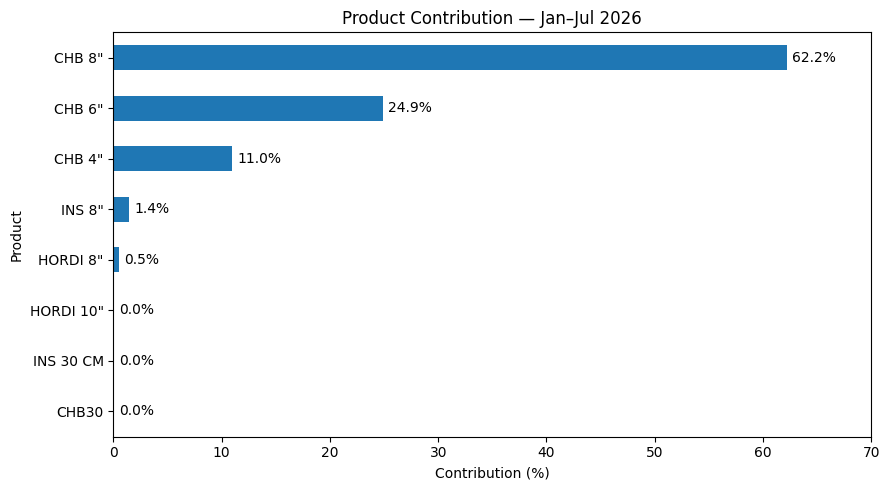

In [12]:
import matplotlib.pyplot as plt

# Product contribution chart
plt.figure(figsize=(9, 5))

product_contribution.sort_values().plot(kind="barh")

plt.title("Product Contribution — Jan–Jul 2026")
plt.xlabel("Contribution (%)")
plt.ylabel("Product")
plt.xlim(0, 70)

# Add percentage labels
for i, value in enumerate(product_contribution.sort_values()):
    plt.text(value + 0.5, i, f"{value:.1f}%", va="center")

plt.tight_layout()
plt.show()

In [13]:
# Monthly production totals

monthly_production = (
    df.groupby(df["Date"].dt.to_period("M"))["Total"]
      .sum()
)

monthly_production

Date
2026-01    272618.0
2026-02    266102.0
2026-03    217024.0
2026-04    259084.0
2026-05    268222.0
2026-06    316664.0
2026-07    268010.0
Freq: M, Name: Total, dtype: float64

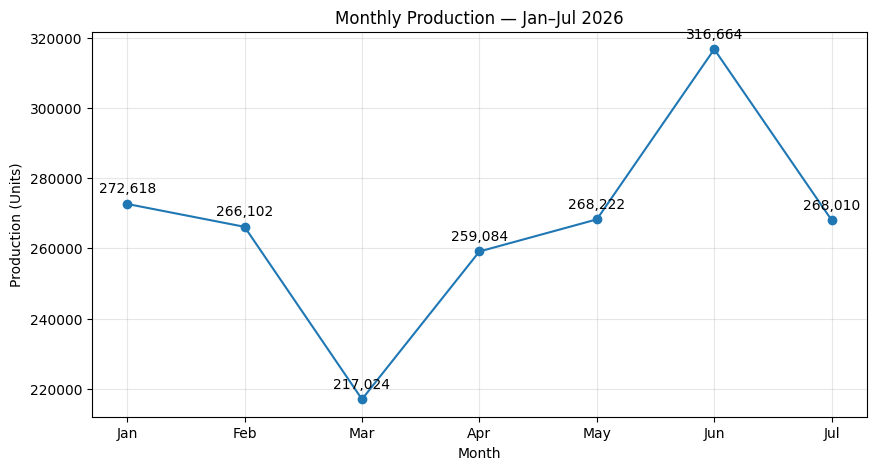

In [14]:
import matplotlib.pyplot as plt

# Monthly production trend
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(monthly_production))
y = monthly_production.values

ax.plot(x, y, marker="o")

# Month labels
ax.set_xticks(x)
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul"])

ax.set_title("Monthly Production — Jan–Jul 2026")
ax.set_xlabel("Month")
ax.set_ylabel("Production (Units)")

ax.grid(True, alpha=0.3)

# Add value labels
for i, value in enumerate(y):
    ax.annotate(
        f"{value:,.0f}",
        (i, value),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )

plt.show()

In [15]:
# Production by day of week

day_production = (
    df.groupby(df["Date"].dt.day_name())["Total"]
      .sum()
)

# Put days in calendar order
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

day_production = day_production.reindex(day_order)

day_production

Date
Monday       330192.0
Tuesday      291340.0
Wednesday    292088.0
Thursday     326360.0
Friday            0.0
Saturday     313080.0
Sunday       314664.0
Name: Total, dtype: float64

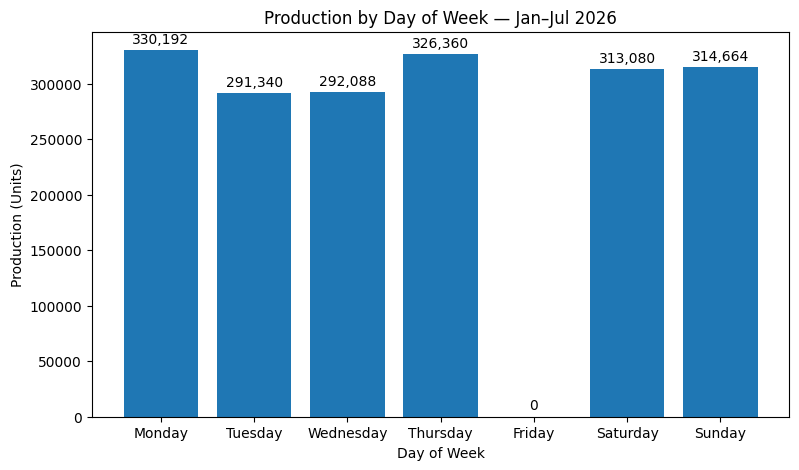

In [16]:
# Production by day of week

fig, ax = plt.subplots(figsize=(9, 5))

x = range(len(day_production))
y = day_production.values

ax.bar(x, y)

ax.set_xticks(x)
ax.set_xticklabels(day_order)

ax.set_title("Production by Day of Week — Jan–Jul 2026")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Production (Units)")

# Add value labels
for i, value in enumerate(y):
    ax.annotate(
        f"{value:,.0f}",
        (i, value),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center"
    )

plt.show()

In [17]:
# Monthly production-day analysis

monthly_production_days = (
    df[df["Total"] > 0]
    .groupby(df.loc[df["Total"] > 0, "Date"].dt.to_period("M"))
    .size()
)

monthly_average = (
    monthly_production
    .div(monthly_production_days)
    .round(0)
)

monthly_production_days, monthly_average

(Date
 2026-01    26
 2026-02    23
 2026-03    22
 2026-04    26
 2026-05    22
 2026-06    26
 2026-07    26
 Freq: M, dtype: int64,
 Date
 2026-01    10485.0
 2026-02    11570.0
 2026-03     9865.0
 2026-04     9965.0
 2026-05    12192.0
 2026-06    12179.0
 2026-07    10308.0
 Freq: M, dtype: float64)

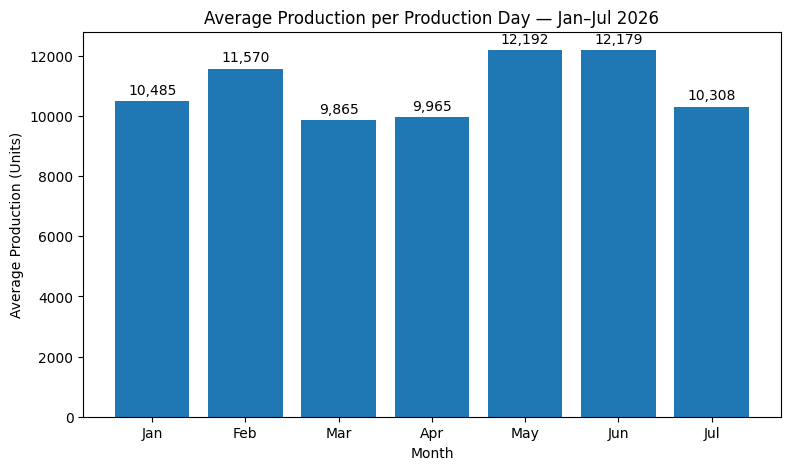

In [18]:
# Average production per production day by month

fig, ax = plt.subplots(figsize=(9, 5))

x = range(len(monthly_average))
y = monthly_average.values

ax.bar(x, y)

ax.set_xticks(x)
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul"])

ax.set_title("Average Production per Production Day — Jan–Jul 2026")
ax.set_xlabel("Month")
ax.set_ylabel("Average Production (Units)")

# Add value labels
for i, value in enumerate(y):
    ax.annotate(
        f"{value:,.0f}",
        (i, value),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center"
    )

plt.show()

## Key Findings

- Total production from January to July 2026 was **1,867,724 units** across **171 production days**.
- There were There were 41 zero-production days, including regular non-production days and other recorded interruptions.
- **CHB 8"** was the dominant product, contributing **62.2%** of total production.
- **CHB 6"** contributed **24.9%**, while **CHB 4"** contributed **11.0%**.
- **June** recorded the highest monthly production at **316,664 units**.
- **May** recorded the highest average production per production day at **12,192 units**.
- **Friday** recorded zero production during the analysis period.
- The three main products — **CHB 8", CHB 6", and CHB 4"** — accounted for approximately **98%** of total production.

## Conclusion

The analysis shows that production was strongly concentrated in the three main block products, with CHB 8" contributing the largest share of total output. Production performance varied across months, with June recording the highest total production and May achieving the highest average output per production day.

The analysis also identified 41 zero-production days during the period, including regular non-production days and other recorded interruptions. These findings provide a clear view of production patterns and can support future production planning, capacity management, and operational decision-making.

This project demonstrates the use of Python and Pandas to clean, validate, analyze, and visualize real-world manufacturing production data in a portfolio-safe format.
